# **EXPERIMENTO - 01**

In [30]:
# Import das bibliotecas e APIs.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [31]:
# Import do dataset "winequality-red.csv".

df = np.loadtxt("winequality-red.csv", delimiter=",", skiprows=1)

In [32]:
print (df.shape)

(1599, 12)


In [33]:
# Criação da matriz X com as variáveis de entrada e o vetor y com a variável de saída.

X = df[:,0:11]
y = df[:,11]

In [34]:
# Separação do conjunto de treino e teste (70%/30%).

X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.3, random_state=42)

In [35]:
poly = PolynomialFeatures(2, include_bias=False)
X_treino_poly = poly.fit_transform(X_treino)
X_teste_poly = poly.transform(X_teste)

In [36]:
# Padronização das variáveis.

padronizacao = StandardScaler().fit(X_treino_poly)
X_treino_padronizado = padronizacao.transform(X_treino_poly)
X_teste_padronizado = padronizacao.transform(X_teste_poly)

In [37]:
# 6. Treinamento do modelo de regressão linear regularizado.
modelo = LinearRegression(penalty='l1', alpha=0.1)
modelo.fit(X_treino_padronizado, y_treino)

TypeError: LinearRegression.__init__() got an unexpected keyword argument 'penalty'

In [ ]:
# Reporte da acurácia.

print (f" Acurácia: {accuracy_score(y_teste, y_pred):.4f}")

 Acurácia: 0.7100


In [ ]:
# Reporte do Recall.

print (f" Recall: {recall_score (y_teste, y_pred):.4f}")

 Recall: 0.5000


In [ ]:
# Reporte da precision.

print (f" Precision: {precision_score(y_teste, y_pred):.4f}")

 Precision: 0.5970


In [ ]:
cm = confusion_matrix(y_teste, y_pred)

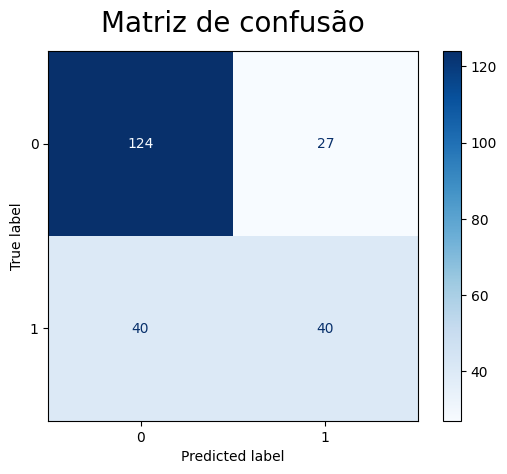

In [ ]:
# Exibição da Matriz de Confusão.

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Matriz de confusão", fontsize=20, y=1.03)
plt.show()


 k: 1 

Acurácia: 0.6364

Recall: 0.4750 

Precision: 0.4750 



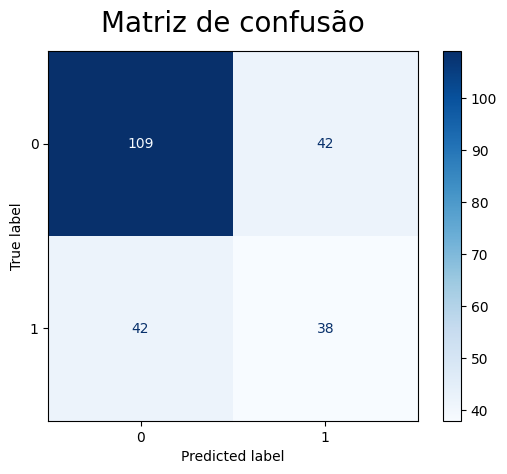


 k: 5 

Acurácia: 0.7013

Recall: 0.5375 

Precision: 0.5733 



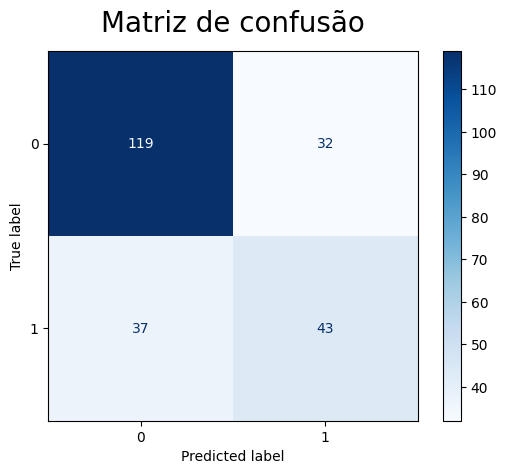


 k: 10 

Acurácia: 0.6970

Recall: 0.4500 

Precision: 0.5806 



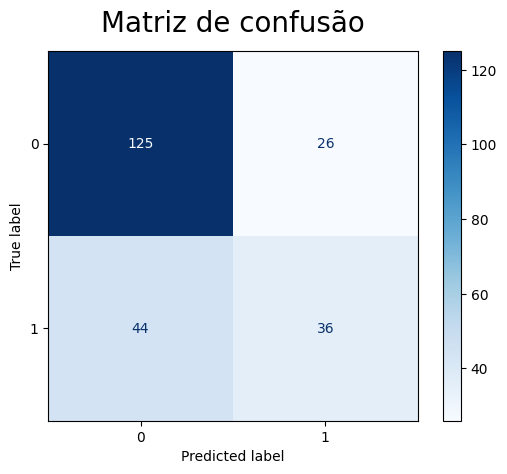


 k: 20 

Acurácia: 0.7100

Recall: 0.4000 

Precision: 0.6275 



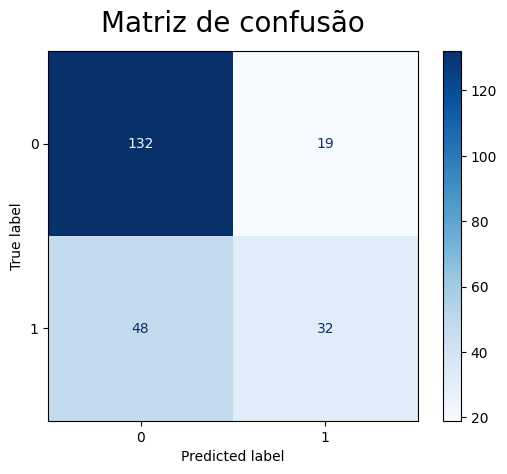

In [ ]:
k = (1, 5, 10, 20)

for i in k:
  print (f"\n", "k:", i, f"\n")

  neigh = KNeighborsClassifier(n_neighbors=i)
  neigh.fit(X_treino_padronizado, y_treino)

  y_pred = neigh.predict(X_teste_padronizado)

  print (f"Acurácia: {accuracy_score(y_teste, y_pred):.4f}" f"\n")

  print (f"Recall: {recall_score (y_teste, y_pred):.4f}", f"\n")

  print (f"Precision: {precision_score(y_teste, y_pred):.4f}", f"\n")

  cm = confusion_matrix(y_teste, y_pred)

  disp = ConfusionMatrixDisplay(confusion_matrix=cm)
  disp.plot(cmap='Blues')
  plt.title("Matriz de confusão", fontsize=20, y=1.03)
  plt.show()